# HR Salary Analysis using Hypothesis Testing

## Problem Statement

Many organizations face concerns regarding salary fairness across departments and genders.

This project aims to analyze employee salary data and identify whether salary differences are statistically significant based on gender and department.

## Objective

- Analyze salary distribution
- Compare salaries across genders
- Perform hypothesis testing
- Generate business insights

In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [230]:
from scipy import stats

### Step 1: Load the Dataset

In [231]:
df = df = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\HR_SALARY_ANALYSIS\DATA\WA_Fn-UseC_-HR-Employee-Attrition.csv")

### Step 2: Data Overview

In [232]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (1470, 35)

Column Names:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data Types:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber    

### Step 3: Select Relevant Columns

In [233]:
df_filtered = df[['Gender', 'Department', 'JobRole', 'MonthlyIncome', 'TotalWorkingYears', 'JobLevel']]
df_filtered.head()

,Gender,Department,JobRole,MonthlyIncome,TotalWorkingYears,JobLevel
0,Female,Sales,Sales Executive,5993,8,2
1,Male,Research & Development,Research Scientist,5130,10,2
2,Male,Research & Development,Laboratory Technician,2090,7,1
3,Female,Research & Development,Research Scientist,2909,8,1
4,Male,Research & Development,Laboratory Technician,3468,6,1


### Step 4: Exploratory Data Analysis (EDA)

In [234]:
print("Monthly Income Stats:")
print(df_filtered['MonthlyIncome'].describe())

Monthly Income Stats:
count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64


### 4.1 Salary Distribution by Gender

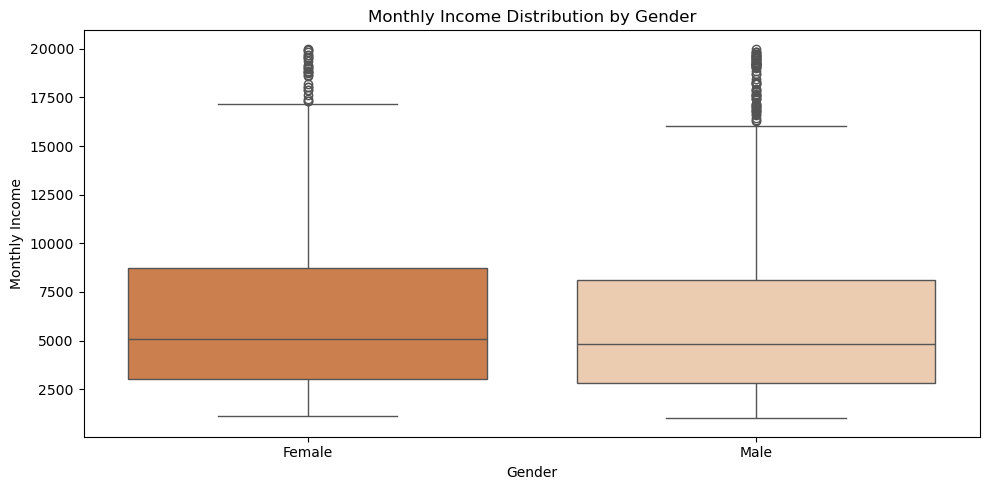

In [235]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Gender', y='MonthlyIncome', data=df_filtered, palette=['#E07B39', '#F5CBA7'])
plt.title('Monthly Income Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('../Images/salary_by_gender.png')
plt.show()

**Observation:**
- Both male and female employees show similar median monthly income (~5000).
- Female employees have a slightly wider salary range in the upper half, indicating more variation at higher salary levels.
- Both groups have high-income outliers above 17500, suggesting a few very high earners in both genders.
- Visually, the difference looks small - we will confirm this with hypothesis testing.

### 4.2 Salary Distribution by Department

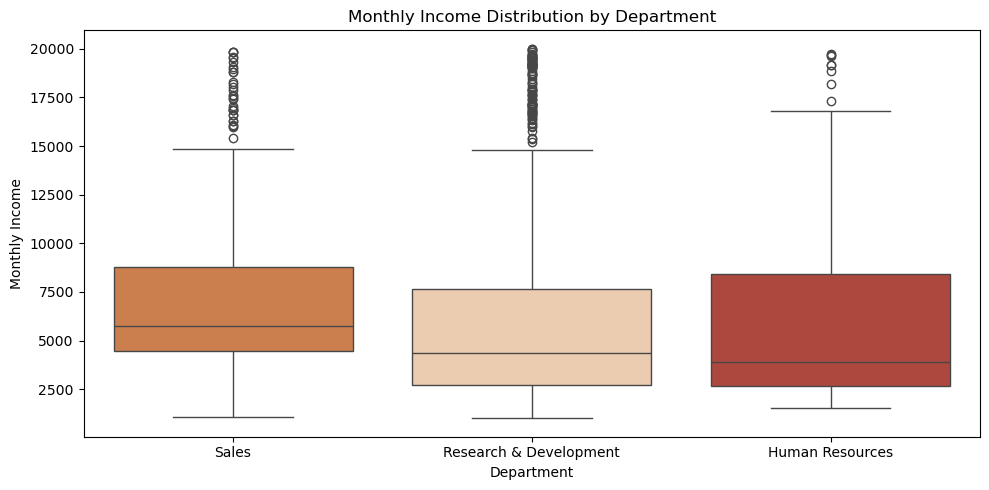

In [236]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Department', y='MonthlyIncome', data=df_filtered, palette=['#E07B39', '#F5CBA7', '#C0392B'])
plt.title('Monthly Income Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('../Images/salary_by_department.png')
plt.show()

**Observation:**
- Sales department has the highest median salary among the three departments.
- Research & Development has the widest salary range, indicating large variation between junior and senior roles.
- Human Resources has the lowest median salary overall.
- Department-wise differences look visible - we will confirm with ANOVA test in hypothesis testing.

### 4.3 Average Salary by Gender and Department

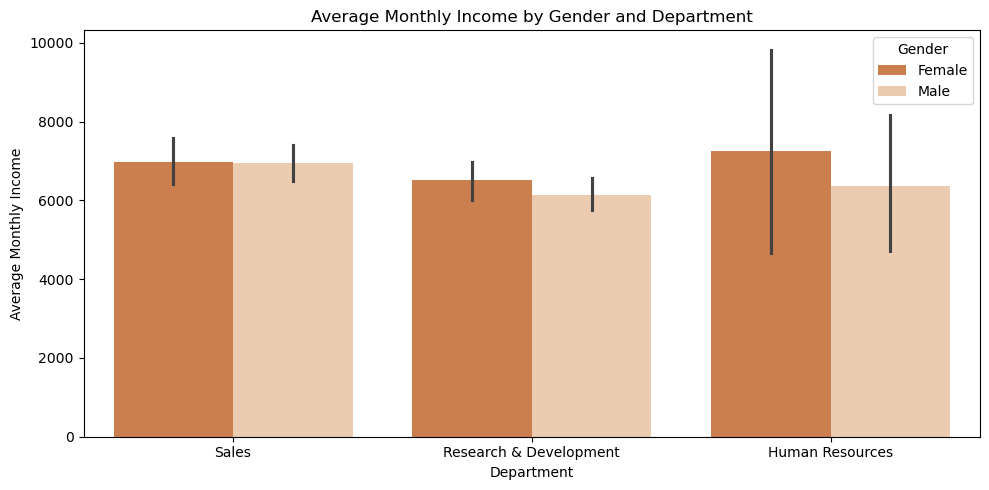

In [237]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Department', y='MonthlyIncome', hue='Gender', data=df_filtered, palette=['#E07B39', '#F5CBA7'])
plt.title('Average Monthly Income by Gender and Department')
plt.xlabel('Department')
plt.ylabel('Average Monthly Income')
plt.tight_layout()
plt.savefig('../Images/salary_gender_department.png')
plt.show()

**Observation:**
- In Sales and Research & Development, male and female average salaries are very close to each other.
- In Human Resources, female average salary is noticeably higher than male.
- No department shows a consistent pattern of one gender earning significantly more.
- This suggests gender may not be the primary driver of salary differences — department and job role likely matter more.
- We will confirm this with hypothesis testing.

## Step 5: Hypothesis Testing

### 5.1 Gender vs Salary (T-Test)

**Null Hypothesis (H0):** There is no significant difference in average salary between Male and Female employees.

**Alternate Hypothesis (H1):** There is a significant difference in average salary between Male and Female employees.

In [238]:
male_salary = df_filtered[df_filtered['Gender'] == 'Male']['MonthlyIncome']
female_salary = df_filtered[df_filtered['Gender'] == 'Female']['MonthlyIncome']

t_stat, p_value = stats.ttest_ind(male_salary, female_salary)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Reject Null Hypothesis — Significant difference exists.")
else:
    print("Result: Fail to Reject Null Hypothesis — No significant difference.")

T-Statistic: -1.2213
P-Value: 0.2222
Result: Fail to Reject Null Hypothesis — No significant difference.


**Result Interpretation:**
- P-Value is 0.2222 which is greater than 0.05.
- We fail to reject the Null Hypothesis.
- This means there is no statistically significant difference in salary between male and female employees.
- Gender alone is NOT a significant factor in salary differences at this company.

### 5.2 Department vs Salary (ANOVA Test)

**Null Hypothesis (H0):** There is no significant difference in average salary across departments.

**Alternate Hypothesis (H1):** At least one department has a significantly different average salary.

In [239]:
sales = df_filtered[df_filtered['Department'] == 'Sales']['MonthlyIncome']
rd = df_filtered[df_filtered['Department'] == 'Research & Development']['MonthlyIncome']
hr = df_filtered[df_filtered['Department'] == 'Human Resources']['MonthlyIncome']

f_stat, p_value = stats.f_oneway(sales, rd, hr)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Reject Null Hypothesis — Significant difference exists across departments.")
else:
    print("Result: Fail to Reject Null Hypothesis — No significant difference.")

F-Statistic: 3.2018
P-Value: 0.0410
Result: Reject Null Hypothesis — Significant difference exists across departments.


**Result Interpretation:**
- P-Value is 0.0410 which is less than 0.05.
- We reject the Null Hypothesis.
- This means there is a statistically significant difference in salary across departments.
- Department is a significant factor in determining employee salary.
- Sales department employees tend to earn more compared to Research & Development and Human Resources.

## Step 6: Conclusion and Business Recommendations

### Key Findings:
- Gender does NOT significantly impact salary (P-Value = 0.2222).
- Department DOES significantly impact salary (P-Value = 0.0410).
- Sales department has the highest average salary.
- Human Resources has the lowest average salary.

### Business Recommendations:
1. **Salary Audit by Department:** HR should regularly audit salary structures across departments to ensure fairness.
2. **Gender Pay Gap:** No significant gender pay gap was found — this is a positive sign for the organization.
3. **HR Department Compensation:** Human Resources employees are underpaid compared to other departments , company should review their compensation structure.
4. **Transparent Pay Policy:** Company should maintain clear salary bands for each department and job role to avoid future disparities.